<a href="https://colab.research.google.com/github/Kush27110405/KUSH_SCIFOR/blob/main/ML%20%2B%20Statistics%20Test%20(19th%20July)/MLAndStatisticsPracticalTest19thJuly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
Q1:- Implementation of MLR
"""

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Mean Squared Error: 0.5558915986952444
R^2 Score: 0.5757877060324508


In [4]:

"""
 Q2:- Decision Tree and Hyperparameter Tuning
"""

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set up the hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'auto', 'sqrt', 'log2']
}

# Perform hyperparameter tuning using GridSearchCV
model = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Best Parameters:", grid_search.best_params_)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mean Squared Error: 0.40840458615620523
R^2 Score: 0.6883380738855668


In [2]:
"""
Q3:- Implementation of Naive Bayes
"""

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Convert the continuous target variable into discrete bins
y_binned = pd.cut(y, bins=5, labels=False)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binned, test_size=0.2)

# Create and train the Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.2923934108527132
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.17      0.26       916
           1       0.72      0.04      0.08      1555
           2       0.25      0.91      0.39       907
           3       0.32      0.23      0.27       396
           4       0.55      0.21      0.30       354

    accuracy                           0.29      4128
   macro avg       0.49      0.31      0.26      4128
weighted avg       0.54      0.29      0.22      4128



In [1]:
"""
Q4:- Implementation of SVM
"""

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Convert the continuous target variable into discrete bins
y_binned = pd.cut(y, bins=5, labels=False)

# Take a smaller subset of the dataset to speed up the training process
X, _, y, _ = train_test_split(X, y_binned, train_size=0.1, random_state=42, stratify=y_binned)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the SVM model with 'rbf' kernel
model = SVC(kernel='rbf', gamma='auto')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.6513317191283293
Confusion Matrix:
 [[ 56  22   0   0   0]
 [ 16 128  24   1   0]
 [  0  34  63   5   0]
 [  0   4  20   6   4]
 [  0   0  12   2  16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75        78
           1       0.68      0.76      0.72       169
           2       0.53      0.62      0.57       102
           3       0.43      0.18      0.25        34
           4       0.80      0.53      0.64        30

    accuracy                           0.65       413
   macro avg       0.64      0.56      0.58       413
weighted avg       0.65      0.65      0.64       413



In [5]:
"""
Q6:- Handling missing values
"""

import pandas as pd
import numpy as np

# Create a small dataset with missing values
data = {
    'A': [1, 2, np.nan, 4, 5],
    'B': [np.nan, 2, 3, 4, np.nan],
    'C': [1, np.nan, np.nan, 4, 5],
    'D': [1, 2, 3, 4, 5]
}

df = pd.DataFrame(data)

# Display the original dataset
print("Original Dataset:")
print(df)

# Handling missing values

# 1. Drop rows with missing values
df_dropna = df.dropna()
print("\nDataset after dropping rows with missing values:")
print(df_dropna)

# 2. Fill missing values with the mean
df_fill_mean = df.copy()
df_fill_mean['A'].fillna(df_fill_mean['A'].mean(), inplace=True)
df_fill_mean['B'].fillna(df_fill_mean['B'].mean(), inplace=True)
df_fill_mean['C'].fillna(df_fill_mean['C'].mean(), inplace=True)
print("\nDataset after filling missing values with mean:")
print(df_fill_mean)

# 3. Fill missing values with the median
df_fill_median = df.copy()
df_fill_median['A'].fillna(df_fill_median['A'].median(), inplace=True)
df_fill_median['B'].fillna(df_fill_median['B'].median(), inplace=True)
df_fill_median['C'].fillna(df_fill_median['C'].median(), inplace=True)
print("\nDataset after filling missing values with median:")
print(df_fill_median)

# 4. Fill missing values with the mode
df_fill_mode = df.copy()
df_fill_mode['A'].fillna(df_fill_mode['A'].mode()[0], inplace=True)
df_fill_mode['B'].fillna(df_fill_mode['B'].mode()[0], inplace=True)
df_fill_mode['C'].fillna(df_fill_mode['C'].mode()[0], inplace=True)
print("\nDataset after filling missing values with mode:")
print(df_fill_mode)


Original Dataset:
     A    B    C  D
0  1.0  NaN  1.0  1
1  2.0  2.0  NaN  2
2  NaN  3.0  NaN  3
3  4.0  4.0  4.0  4
4  5.0  NaN  5.0  5

Dataset after dropping rows with missing values:
     A    B    C  D
3  4.0  4.0  4.0  4

Dataset after filling missing values with mean:
     A    B         C  D
0  1.0  3.0  1.000000  1
1  2.0  2.0  3.333333  2
2  3.0  3.0  3.333333  3
3  4.0  4.0  4.000000  4
4  5.0  3.0  5.000000  5

Dataset after filling missing values with median:
     A    B    C  D
0  1.0  3.0  1.0  1
1  2.0  2.0  4.0  2
2  3.0  3.0  4.0  3
3  4.0  4.0  4.0  4
4  5.0  3.0  5.0  5

Dataset after filling missing values with mode:
     A    B    C  D
0  1.0  2.0  1.0  1
1  2.0  2.0  1.0  2
2  1.0  3.0  1.0  3
3  4.0  4.0  4.0  4
4  5.0  2.0  5.0  5


Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


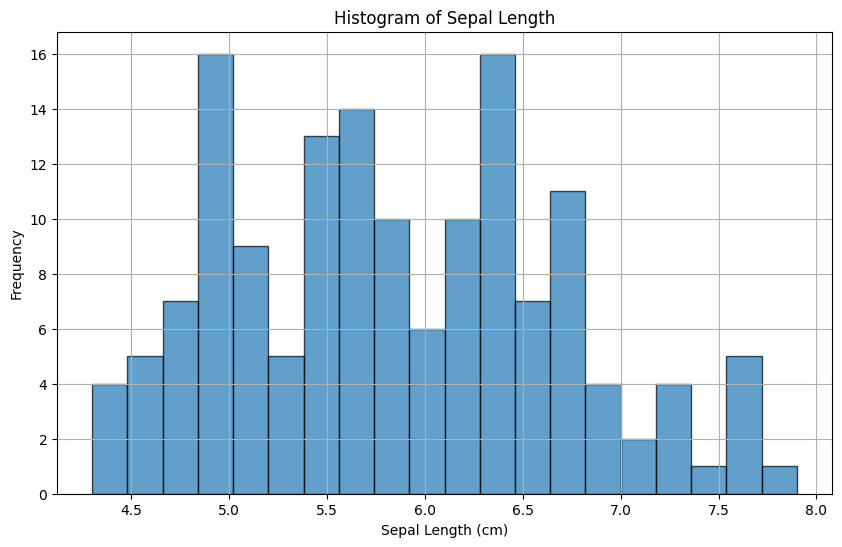

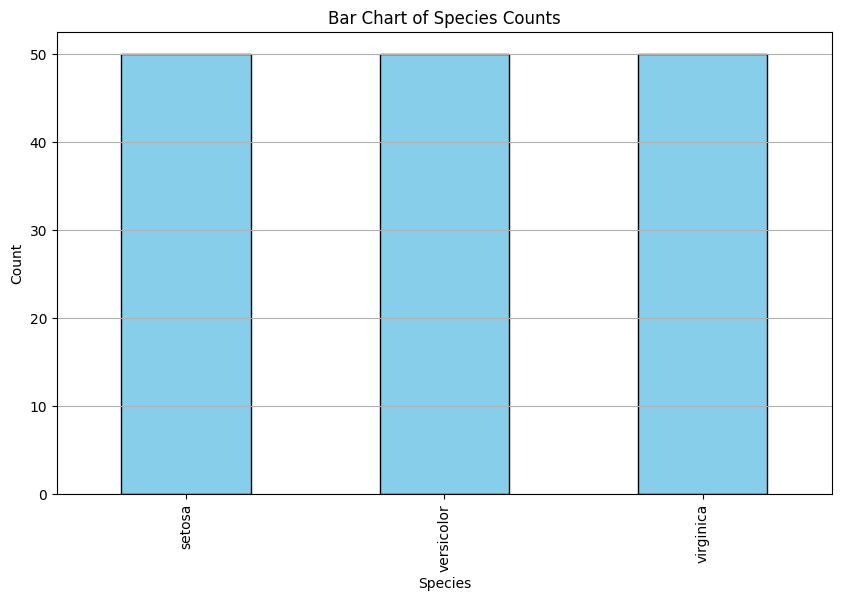

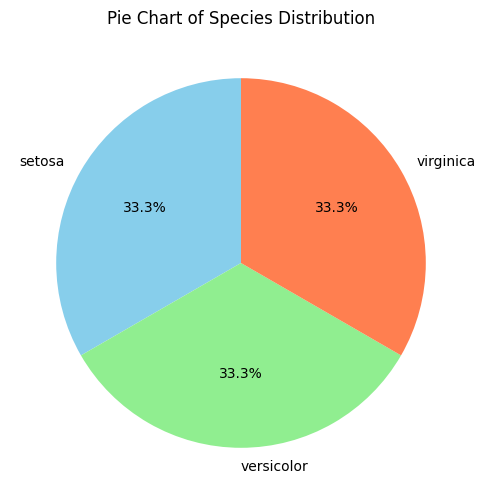

In [6]:
"""
Q7:- Plotting 3 visualizations
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display the first few rows of the dataset
print("Iris Dataset:")
print(df.head())

# Plotting Histogram for 'sepal length (cm)'
plt.figure(figsize=(10, 6))
plt.hist(df['sepal length (cm)'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting Bar Chart for the count of each species
species_counts = df['species'].value_counts()
plt.figure(figsize=(10, 6))
species_counts.plot(kind='bar', color='skyblue', edgecolor='k')
plt.title('Bar Chart of Species Counts')
plt.xlabel('Species')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

# Plotting Pie Chart for the count of each species
plt.figure(figsize=(10, 6))
species_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'coral'])
plt.title('Pie Chart of Species Distribution')
plt.ylabel('')  # Hide the y-label
plt.show()
